In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import f1_score
from sklearn.pipeline import Pipeline
from scipy.sparse import hstack, csr_matrix
import lightgbm as lgb

In [8]:
#Eda
train = pd.read_csv('/kaggle/input/datasets/ashlythangadurai/data-for-input/train.csv')
test = pd.read_csv('/kaggle/input/datasets/ashlythangadurai/data-for-input/test.csv')

#Basic shape and info
print("Train shape:", train.shape)
print("Test shape :", test.shape)
print(train.info())

#First few rows
train.head(5)

#Statistical summary
train.describe()

#Missing values
missing = train.isnull().sum()
print(missing[missing > 0])

Train shape: (198000, 15)
Test shape : (102000, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198000 entries, 0 to 197999
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   created_date  198000 non-null  object
 1   post_id       198000 non-null  int64 
 2   emoticon_1    198000 non-null  int64 
 3   emoticon_2    198000 non-null  int64 
 4   emoticon_3    198000 non-null  int64 
 5   upvote        198000 non-null  int64 
 6   downvote      198000 non-null  int64 
 7   if_1          198000 non-null  int64 
 8   if_2          198000 non-null  int64 
 9   race          52577 non-null   object
 10  religion      52577 non-null   object
 11  gender        52577 non-null   object
 12  disability    198000 non-null  bool  
 13  comment       197999 non-null  object
 14  label         198000 non-null  int64 
dtypes: bool(1), int64(9), object(5)
memory usage: 21.3+ MB
None
race        145423
religion    145423
gen

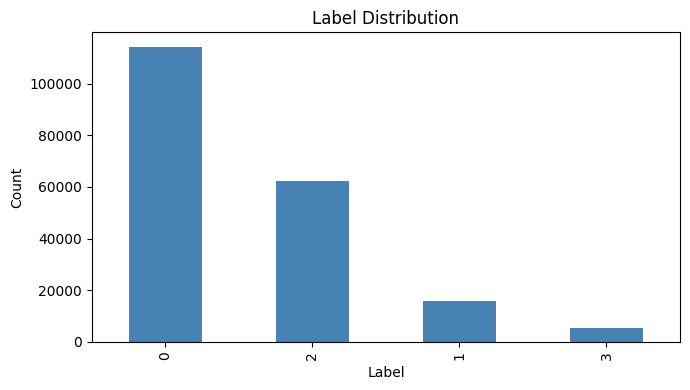

In [9]:
#Target label distribution
plt.figure(figsize=(7, 4))
train['label'].value_counts().plot(kind='bar', color='steelblue')
plt.title('Label Distribution')
plt.xlabel('Label'); plt.ylabel('Count')
plt.tight_layout(); plt.show()

# Target Label Distribution

**Observation:**
The bar chart shows that the four labels are unevenly distributed. Label 0 has the highest number of comments, followed by Label 1, while Labels 2 and 3 have considerably fewer comments. This indicates a clear class imbalance in the dataset.

**Interpretation:**
From this analysis, I learned that the comment-category dataset is imbalanced, with some categories having many more examples than others. This is important for the classification model because a model may perform well on the majority class but have difficulty identifying minority classes. Therefore, evaluation metrics such as precision, recall, and F1-score should be considered along with accuracy, and techniques such as class weighting can be considered if required.

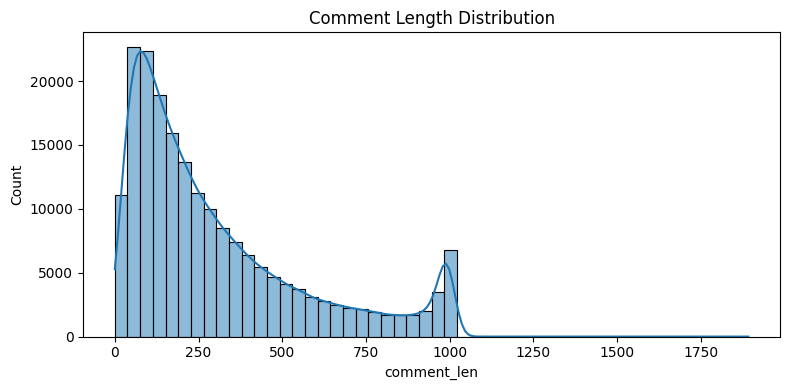

In [10]:
#Comment length distribution
train['comment_len'] = train['comment'].fillna('').str.len()
plt.figure(figsize=(8, 4))
sns.histplot(train['comment_len'], bins=50, kde=True)
plt.title('Comment Length Distribution')
plt.tight_layout(); plt.show()

# Comment Length Distribution

**Observation:**
The histogram shows that most comments are relatively short, with the number of comments decreasing as comment length increases. The distribution is right-skewed, with a long tail representing a smaller number of very long comments.

**Interpretation:**
From this analysis, I learned that comment length varies considerably across the dataset, but most comments contain relatively few characters. Comment length can provide useful contextual information for comment classification because different categories may have different writing patterns. Therefore, comment_len can be included as a numerical feature along with text-based features such as TF-IDF.

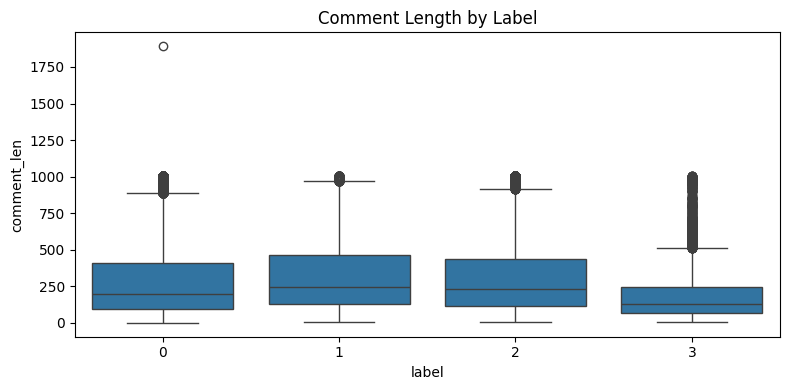

In [11]:
#Comment length per label
plt.figure(figsize=(8, 4))
sns.boxplot(x='label', y='comment_len', data=train)
plt.title('Comment Length by Label')
plt.tight_layout(); plt.show()

# Comment Length by Label

**Observation:**
The box plot shows the distribution of comment lengths for each label. The median comment lengths are relatively close across the four categories, although there are differences in their spread and several longer-comment outliers. Some comments in every category are substantially longer than the typical comment.

**Interpretation:**
From this analysis, I learned that comment length alone does not clearly separate the four categories because the distributions overlap considerably. However, it can still provide supporting information when combined with textual features. Therefore, comment_len can be retained as an additional feature rather than being used as the primary predictor of the comment category.

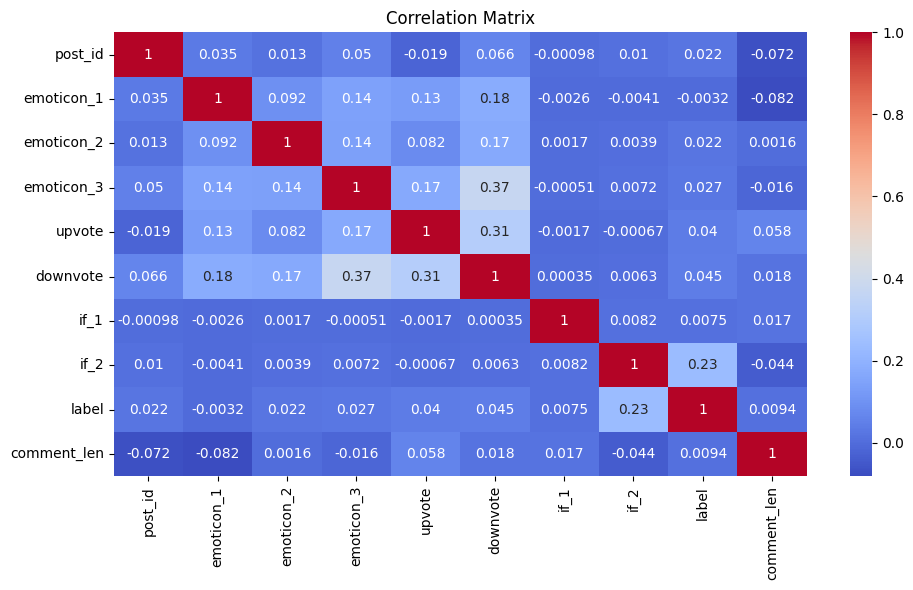

In [12]:
#Correlation heatmap 
num_cols = train.select_dtypes(include=['int64','float64']).columns
plt.figure(figsize=(10, 6))
sns.heatmap(train[num_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.tight_layout(); plt.show()

# Correlation Heatmap

**Observation:**
The correlation matrix shows that most numerical features have weak correlations with the target label. Some relationships, particularly involving the emoticon-related variables, are stronger than others, but there is no single numerical feature that has a very strong linear relationship with the label.

**Interpretation:**
From this analysis, I learned that the comment category cannot be reliably predicted using only simple numerical metadata. Since this is an NLP classification problem, the actual words and phrases in the comments are likely to provide important information for distinguishing between categories. Therefore, text features such as TF-IDF can be used together with numerical and metadata features to improve classification performance.

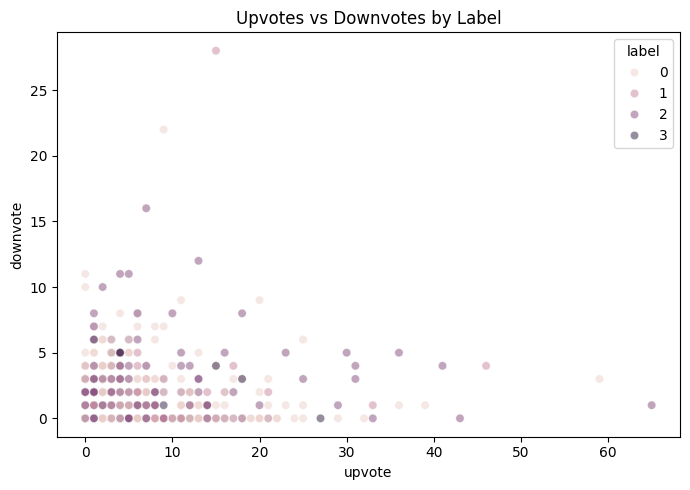

In [13]:
#Upvote vs downvote scatter coloured by label
plt.figure(figsize=(7, 5))
sns.scatterplot(data=train.sample(2000),x='upvote', y='downvote', hue='label', alpha=0.5)
plt.title('Upvotes vs Downvotes by Label')
plt.tight_layout(); plt.show()

# Upvotes vs Downvotes by Label

**Observation:**
The scatter plot shows that most comments have relatively low numbers of both upvotes and downvotes. The points from different labels overlap substantially, although a few comments have unusually high upvote or downvote counts.

**Interpretation:**
From this analysis, I learned that upvotes and downvotes do not show a clear separation between the different comment categories. This suggests that engagement-related features alone may not be sufficient for classification. However, upvote and downvote can still be included as additional metadata features, allowing the model to combine them with the actual textual content of the comments.

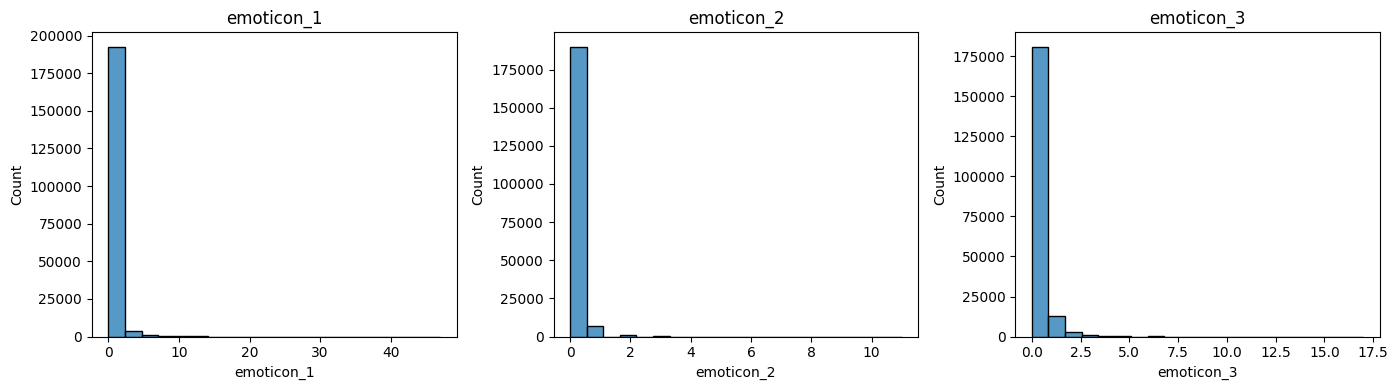

In [14]:
#Emoticon columns count plot
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for i, col in enumerate(['emoticon_1', 'emoticon_2', 'emoticon_3']):
    sns.histplot(train[col], bins=20, ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout(); plt.show()

# Emoticon Distribution

**Observation:**
The three histograms show that the majority of comments contain zero or very few occurrences of emoticon_1, emoticon_2, and emoticon_3. Only a small number of comments contain higher counts, resulting in highly right-skewed distributions with a few extreme values.

**Interpretation:**
From this analysis, I learned that emoticons are relatively sparse features in the dataset. Although most comments do not contain many emoticons, their presence or frequency may still provide useful information for distinguishing certain comment categories. Therefore, the emoticon features can be retained as supplementary metadata features, while the main predictive information is expected to come from the comment text.

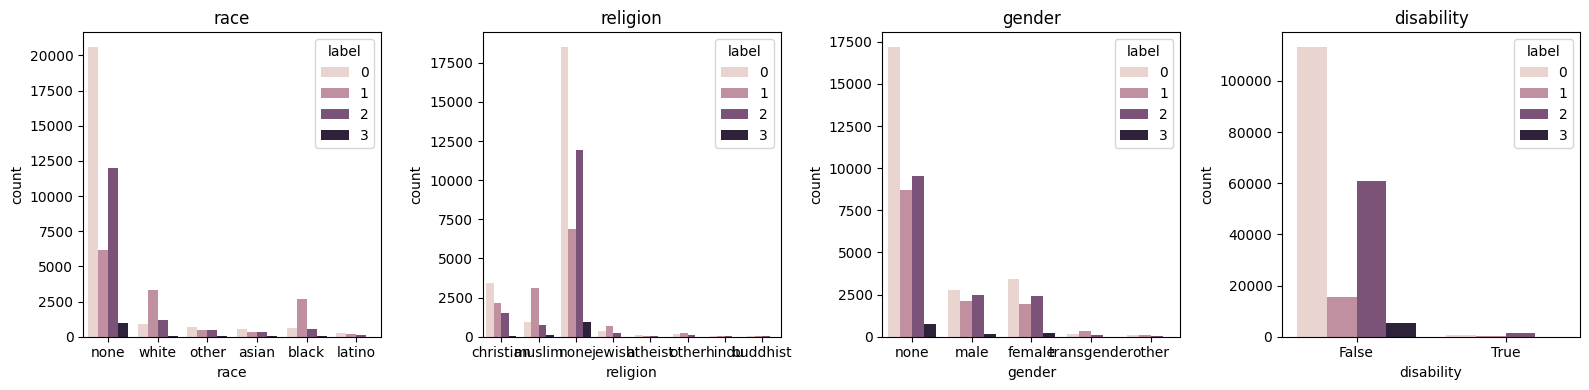

In [15]:
#Bias flag columns vs label
bias_cols = ['race', 'religion', 'gender', 'disability']
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, col in enumerate(bias_cols):
    sns.countplot(x=col, hue='label', data=train, ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout(); plt.show()

# Categorical Features: Race, Religion, Gender and Disability

**Observation:**
The categorical plots show that the distribution of comments across labels varies for different demographic-related features. Some categories contain substantially more observations than others. The disability variable is particularly imbalanced, with most observations belonging to the False category and relatively few belonging to True.

**Interpretation:**
From this analysis, I learned that these categorical features have different distributions across the comment categories and may provide additional information to the classification model. However, because several categories are highly imbalanced, their effect should be interpreted carefully. These variables can be encoded using techniques such as one-hot encoding and combined with text features, while avoiding the assumption that differences in group counts automatically imply a strong predictive relationship.

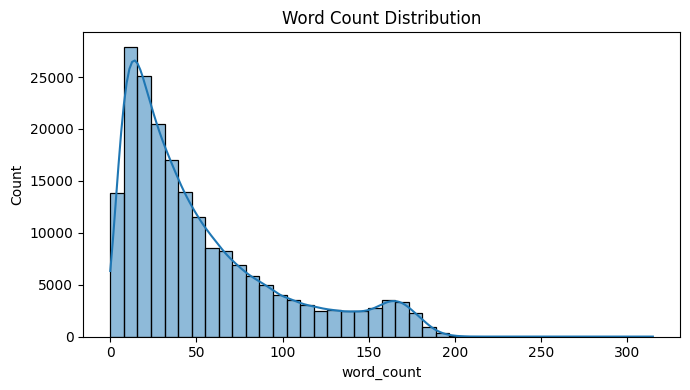

In [16]:
#Word count per comment
train['word_count'] = train['comment'].fillna('').apply(lambda x: len(x.split()))
plt.figure(figsize=(7, 4))
sns.histplot(train['word_count'], bins=40, kde=True)
plt.title('Word Count Distribution')
plt.tight_layout(); plt.show()

# Word Count Distribution

**Observation:**
The histogram shows that most comments contain a relatively small number of words, with the highest concentration occurring at lower word counts. The distribution is right-skewed, with fewer comments containing a large number of words and a long tail extending to approximately 300 words.

**Interpretation:**
From this analysis, I learned that most comments are short, but the dataset also contains a smaller number of long comments. Word count can provide useful information about the structure of comments and can be used as an additional numerical feature. However, because comments with different word counts can belong to the same category, word count alone is not sufficient for classification. Combining word_count with TF-IDF text features allows the model to use both the length of the comment and the actual words used.

In [6]:
#Loading datasets
train = pd.read_csv('/kaggle/input/datasets/ashlythangadurai/data-for-input/train.csv')
test = pd.read_csv('/kaggle/input/datasets/ashlythangadurai/data-for-input/test.csv')
sample = pd.read_csv('/kaggle/input/datasets/ashlythangadurai/sample/Sample.csv')

#Filling missing comments with empty string
train['comment'] = train['comment'].fillna("").astype(str)
test['comment'] = test['comment'].fillna("").astype(str)

#List of features to clean
num_cols = ['emoticon_1','emoticon_2','emoticon_3','upvote','downvote','if_1','if_2','race','religion','gender','disability']
for col in num_cols:
    train[col] = pd.to_numeric(train[col], errors='coerce').fillna(0)
    test[col] = pd.to_numeric(test[col], errors='coerce').fillna(0)

#Feature Engineering 1:finding length of each comment
train['comment_length'] = train['comment'].str.len()
test['comment_length'] = test['comment'].str.len()

#Feature Engineering 2:difference in upvote and downvote
train['vote_diff'] = train['upvote'] - train['downvote']
test['vote_diff'] = test['upvote'] - test['downvote']

#Feature Engineering 3:ratio of upvotes to downvotes
train['vote_ratio'] = train['upvote'] / (train['downvote'] + 1)
test['vote_ratio'] = test['upvote'] / (test['downvote'] + 1)

#encoding target labels to numerical form
le = LabelEncoder()
y = le.fit_transform(train['label'])

#Creating pipeline: TF-IDF and Logistic Regression
lr_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=8000, ngram_range=(1,2),min_df=5, stop_words='english', sublinear_tf=True)),
    ('clf',   LogisticRegression(max_iter=300, solver='saga'))])

#splitting text data
X_train_text, X_val_text, y_train_pipe, y_val_pipe = train_test_split(train['comment'], y, test_size=0.2, random_state=42, stratify=y)

#Training,Predicting and evaluation using F1 score
lr_pipeline.fit(X_train_text, y_train_pipe)
pred_pipeline = lr_pipeline.predict(X_val_text)
print("Logistic Regression Pipeline F1:", f1_score(y_val_pipe, pred_pipeline, average='macro'))

#Converting text into numerical values
tfidf = TfidfVectorizer(max_features=8000, ngram_range=(1,2), min_df=5, stop_words='english', sublinear_tf=True)
X_text_train = tfidf.fit_transform(train['comment'])
X_text_test  = tfidf.transform(test['comment'])

#Converting structured data into sparse format and combine features and split dataset
features = ['emoticon_1','emoticon_2','emoticon_3','upvote','downvote','vote_diff','vote_ratio','if_1','if_2','race','religion','gender','disability','comment_length']
X_other_train = csr_matrix(train[features].astype(np.float32).values)
X_other_test  = csr_matrix(test[features].astype(np.float32).values)

X = hstack([X_text_train, X_other_train])
X_test = hstack([X_text_test,  X_other_test])

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

#Model 1:LightGBM
model1 = lgb.LGBMClassifier(n_estimators=300, learning_rate=0.1, num_leaves=31,subsample=0.9, colsample_bytree=0.9, random_state=42,force_col_wise=True, n_jobs=-1)
model1.fit(X_train, y_train)
pred_val1 = model1.predict(X_val)
print("LightGBM F1:", f1_score(y_val, pred_val1, average='macro'))

#Model 2: Logistic Regression
model2 = LogisticRegression(max_iter=300, solver='saga')
model2.fit(X_train, y_train)
pred_val2 = model2.predict(X_val)
print("Logistic F1:", f1_score(y_val, pred_val2, average='macro'))

#Model 3: Naive Bayes
X_train_nb = X_train.copy()
X_val_nb   = X_val.copy()
X_train_nb.data = np.abs(X_train_nb.data)
X_val_nb.data   = np.abs(X_val_nb.data)
model3 = MultinomialNB()
model3.fit(X_train_nb, y_train)
pred_val3 = model3.predict(X_val_nb)
print("NaiveBayes F1:", f1_score(y_val, pred_val3, average='macro'))

#Training on whole data and prediction on test set
model1.fit(X, y)
pred = model1.predict(X_test)

#coverting numeric labels back to original categories and saving.
pred = le.inverse_transform(pred)
sample['label'] = pred
sample.to_csv("submission.csv", index=False)
print("submission.csv created successfully")

Logistic Regression Pipeline F1: 0.6584545491149955
[LightGBM] [Info] Total Bins 711554
[LightGBM] [Info] Number of data points in the train set: 158400, number of used features: 8011
[LightGBM] [Info] Start training from score -0.550557
[LightGBM] [Info] Start training from score -2.520769
[LightGBM] [Info] Start training from score -1.154061
[LightGBM] [Info] Start training from score -3.589217


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM F1: 0.8051834429296026


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Logistic F1: 0.33526431329984346
NaiveBayes F1: 0.41827416332824335
[LightGBM] [Info] Total Bins 825346
[LightGBM] [Info] Number of data points in the train set: 198000, number of used features: 8011
[LightGBM] [Info] Start training from score -0.550552
[LightGBM] [Info] Start training from score -2.520816
[LightGBM] [Info] Start training from score -1.154061
[LightGBM] [Info] Start training from score -3.589171


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


submission.csv created successfully


# Model Performance and Final Prediction

**Observation:**
The model comparison shows that Logistic Regression achieved an F1-score of 0.6585, while the final LightGBM model achieved a higher F1-score of 0.8052. Naive Bayes and another Logistic Regression experiment produced lower F1-scores of 0.4183 and 0.3353, respectively. The final LightGBM model was trained on 198,000 records with 8,011 features, and the predictions were successfully generated and saved as submission.csv.

**Interpretation:**
From this analysis, I learned that LightGBM was able to capture the patterns in the text-derived and metadata features more effectively than the other tested models. Its higher F1-score indicates better classification performance across the comment categories. Therefore, LightGBM was used for the final prediction, and the successful creation of submission.csv confirms the completion of the NLP comment-category prediction pipeline.